KNN
1. Dataset Loading and Preprocessing
Load the MNIST dataset and split it into training, and test sets(70-30). Inspect the shape of
the dataset and display a few sample images with their corresponding labels. Normalize the
pixel values and investigate whether feature scaling affects KNN performance

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [26]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784',version=1,as_frame=False)


In [27]:
X = mnist.data
y = mnist.target.astype(int)

In [28]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

(70000, 784)
label: 0


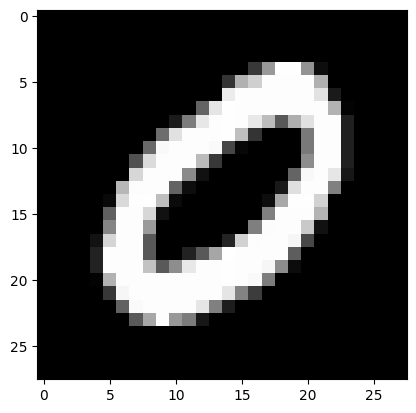

In [29]:
print(X.shape)

plt.imshow(X_train[0].reshape(28,28),cmap='gray')
print(f"label: {y_train[0]}")

label: 4


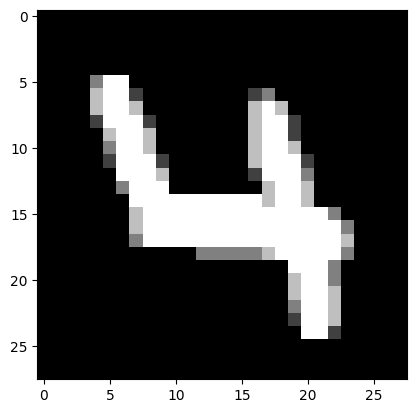

In [30]:
plt.imshow(X_train[1].reshape(28,28),cmap='gray')
print(f"label: {y_train[1]}")

The dataset is of size 7000 X 784 which is 7000 images of total 784 pixels 28*28=784 so we can have a 28 x 28 size image.

2. Implement KNN from Scratch
Implement the K-Nearest Neighbors (KNN) algorithm from scratch without using a pre-built
KNN classifier. Your implementation should:
1
(a) Calculate the Euclidean distance between samples.
(b) Find the k nearest training samples.
(c) Predict the class using majority voting.

In [157]:
class KNN:
    def __init__(self,Train_set,Train_labels,K,metric):
        self.train=Train_set
        self.label=Train_labels
        self.Kcount=K
        self.metric=metric
        
    def dist(self,sample):
        if self.metric=="Euclidean":
            X_sq=np.sum(self.train**2,axis=1)
            smpl_sq=np.sum(sample**2)
            dot_prdt=np.dot(self.train,sample)
            dist_sq=X_sq+smpl_sq-2*(dot_prdt)
            return (dist_sq)**0.5
        elif self.metric=="Manhattan":
            dist=np.sum(np.abs(self.train-sample),axis=1)
            return dist
        
    def k_nearest(self,sample):
        dist_array=self.dist(sample).astype(float)
        labels=[]
        for i in range(self.Kcount):
            ind = np.argmin(dist_array)
            labels.append(self.label[ind])
            dist_array[ind]=float('inf')
        return labels
    def predict(self,sample):
        neigh=self.k_nearest(sample)
        voting={}
        for lbl in neigh:
            if lbl not in voting:
                voting[lbl]=1
            voting[lbl]+=1
        return max(voting)

In [158]:
K1=KNN(X_train,y_train,1,"Manhattan")


In [159]:
sample=X_test[0]
sample_lbl=y_test[0]

print(K1.predict(sample))
print(sample_lbl)

8
8


Evaluate your implementation on a subset of MNIST(try taking 5000 train points and
200 test points) and report the classification accuracy and confusion matrix.

In [160]:
x_trn_sub=X_train[:5000,]
y_trn_sub=y_train[:5000,]
x_test_sub=X_test[:200,]
y_test_sub=y_test[:200,]

In [161]:
K2=KNN(x_trn_sub,y_trn_sub,7,"Euclidean")

In [162]:
correct=0
total=200
confusion_arr=[]
for i,sample in enumerate(x_test_sub):
    pred_lbl=K2.predict(sample)
    true_lbl=y_test_sub[i]
    if pred_lbl == true_lbl:
        correct+=1
    confusion_arr.append((true_lbl,pred_lbl))
acc = (correct/total)*100
print(f"Accuracy : {acc}%")

Accuracy : 86.5%


In [163]:
confusion = np.zeros((10, 10), dtype=int)
for x,y in confusion_arr:
    i=x-1
    j=y-1
    confusion[i][j]+=1
print(confusion)

[[23  0  0  0  0  0  0  0  0  0]
 [ 0 17  0  0  0  0  0  0  0  0]
 [ 0  0 13  0  7  0  1  3  0  0]
 [ 0  0  0 14  0  0  0  1  0  0]
 [ 0  0  0  0 19  1  0  0  0  0]
 [ 0  0  0  0  0 18  0  1  0  0]
 [ 0  0  0  0  0  0 16  1  5  0]
 [ 0  0  0  0  0  0  0 16  4  0]
 [ 0  0  0  0  0  0  1  0 19  0]
 [ 0  0  0  0  0  2  0  0  0 18]]


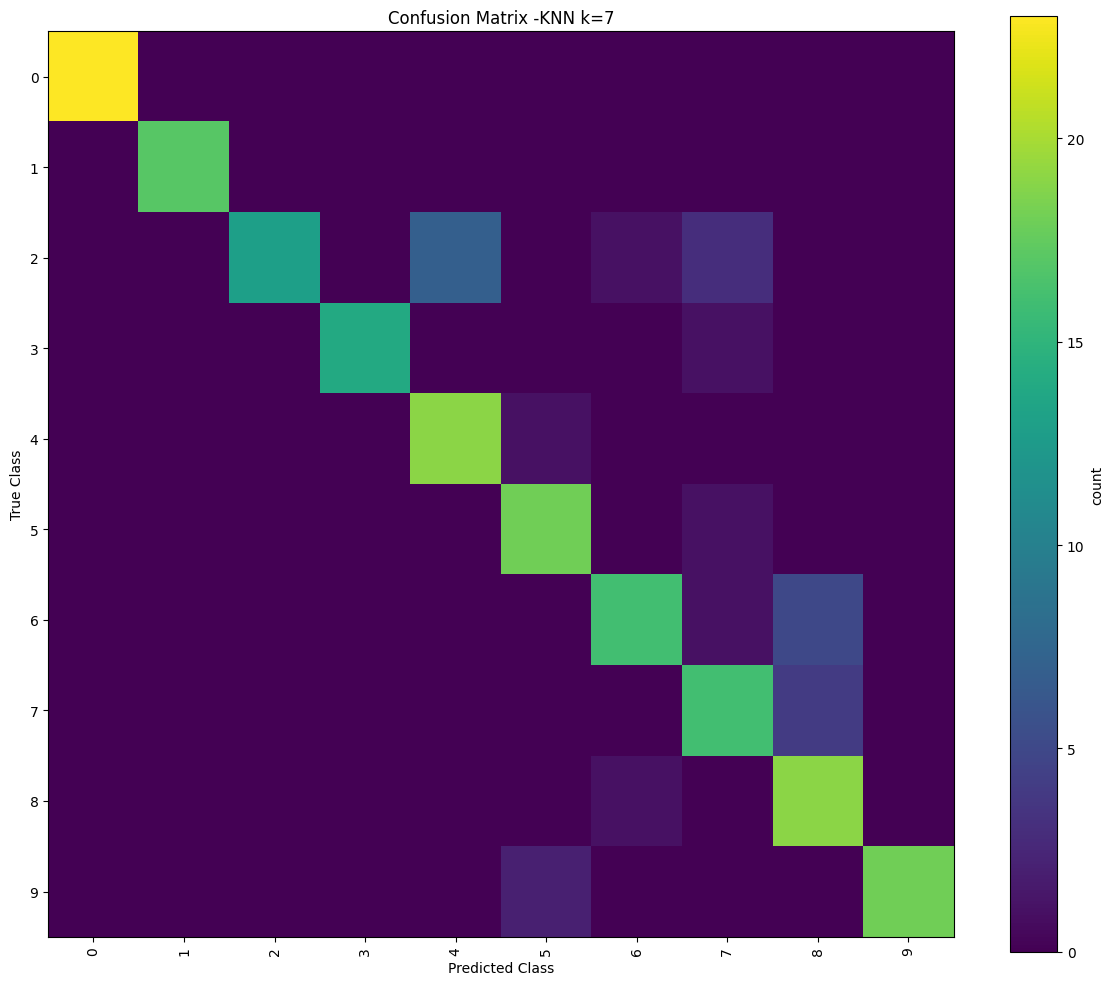

In [164]:
plt.figure(figsize=(12, 10))
plt.imshow(confusion)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix -KNN k=7")

plt.xticks(range(10), range(0, 10), rotation=90)
plt.yticks(range(10), range(0, 10))

plt.colorbar(label="count")
plt.tight_layout()
plt.show()

3. Choosing the Value of k
Evaluate KNN using multiple values of k, for example
k ∈ {1, 3, 5, 7, 9, 11}.
Plot the test error against k for
k = 1, 2, . . . , N.
Identify the value of k that gives the lowest test error and briefly explain why very small and
very large values of k can lead to overfitting and underfitting, respectively

In [165]:
N=17
K=[]
err=[]
for k in range(1,N+1):
    K.append(k)
    correct=0
    total=200
    confusion_arr=[]
    for i,sample in enumerate(x_test_sub):
        classify=KNN(x_trn_sub,y_trn_sub,k,"Euclidean")
        pred_lbl=classify.predict(sample)
        true_lbl=y_test_sub[i]
        if pred_lbl == true_lbl:
            correct+=1
        confusion_arr.append((true_lbl,pred_lbl))
    acc = (correct/total)*100
    err.append(100-acc)


Text(0, 0.5, 'error %')

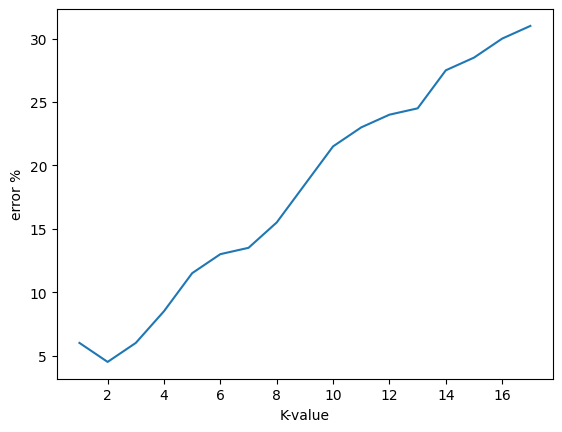

In [166]:
plt.plot(K,err)
plt.xlabel("K-value")
plt.ylabel("error %")

At K value=2 the lowest error is observed. Very large values of k can include more distinct labels therefore confusing the model on what is the correct label.
and low k value will give very few choices to choose from and therefore pushing the model to memorize and cause overfitting.


4. Investigate Distance Metrics
Compare KNN using different distance metrics:
• Euclidean distance
• Manhattan distance
You may find the following link useful
https://www.geeksforgeeks.org/data-science/manhattan-distance/ Manhattan Distance
Evaluate both methods using the same value of k and compare their test accuracy. Briefly
explain how the choice of distance metric affects KNN predictions and which metric performs
better on the MNIST dataset.

In [167]:
#k= 4
Eclid=KNN(x_trn_sub,y_trn_sub,4,"Euclidean")
Manhat=KNN(x_trn_sub,y_trn_sub,4,"Manhattan")

In [168]:
correct_ecld=0
correct_manhat=0
total=200
for i,sample in enumerate(x_test_sub):
    pred_lbl_ecld=Eclid.predict(sample)
    pred_lbl_manhat=Manhat.predict(sample)
    true_lbl=y_test_sub[i]
    if pred_lbl_ecld == true_lbl:
        correct_ecld+=1
    if pred_lbl_manhat==true_lbl:
        correct_manhat+=1
acc_ecld = (correct_ecld/total)*100
acc_manhat = (correct_manhat/total)*100
print(f"Accuracy Euclidean : {acc_ecld}%")
print(f"Accuracy manhat : {acc_manhat}%")

Accuracy Euclidean : 91.5%
Accuracy manhat : 91.5%


5. Final Analysis
Summarize the results of all experiments in a table containing the feature scaling method,
number of features, best value of k, test accuracy, and prediction time.
Finally, answer the following:
• What value of k performed best?
• Did feature scaling improve KNN performance on MNIST?
• What are the main advantages and disadvantages of KNN for image classification?


question 1's scaling part

In [172]:
x_trn_sub=X_train[:5000,]/255.0
y_trn_sub=y_train[:5000,]
x_test_sub=X_test[:200,]/255.0
y_test_sub=y_test[:200,]

In [170]:
K2=KNN(x_trn_sub,y_trn_sub,7,"Euclidean")

In [171]:
correct=0
total=200
confusion_arr=[]
for i,sample in enumerate(x_test_sub):
    pred_lbl=K2.predict(sample)
    true_lbl=y_test_sub[i]
    if pred_lbl == true_lbl:
        correct+=1
    confusion_arr.append((true_lbl,pred_lbl))
acc = (correct/total)*100
print(f"Accuracy : {acc}%")

Accuracy : 86.5%
